In [2]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [3]:
# import necessary modules

import yfinance as yf
import os
import pandas as pd



In [4]:
# Data Pre-processing

from sklearn.preprocessing import StandardScaler

# Load the dataset
file_path = "/Users/gauravacharya/Desktop/btc.csv"  # Replace with your dataset path
df = pd.read_csv(file_path)

import pandas as pd

# Assuming df is your DataFrame and 'datetime_column_name' is the name of your datetime column
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].astype('int64') // 10**9


# Handle missing values
df.fillna(method='ffill', inplace=True)

# Creating a new target column (modify this according to your analysis needs)
df['Target'] = (df['Close'] > df['Open']).astype(int)

# Scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['Open', 'High', 'Low', 'Close', 'Volume']])

# Split the data into features and target
X = scaled_features
y = df['Target']

# The data is now preprocessed


/var/folders/qs/75m9hxcs4sjcq7swy5j7nr2w0000gn/T/ipykernel_34777/774196567.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [5]:
# Feature Selection

from sklearn.feature_selection import SelectKBest, f_classif

# Print all column names in the DataFrame
print("Column names in the DataFrame:")
print(df.columns)

# Replace 'target' with the actual name of your target column
target_column_name = 'close'  # Change this to the actual name of your target column

if target_column_name in df.columns:
    X = df.drop(target_column_name, axis=1)  # Feature matrix
    y = df[target_column_name]  # Target variable

    # Rest of your code for feature selection...
else:
    print(f"Column '{target_column_name}' not found in the DataFrame.")


Column names in the DataFrame:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Target'],
      dtype='object')
Column 'close' not found in the DataFrame.


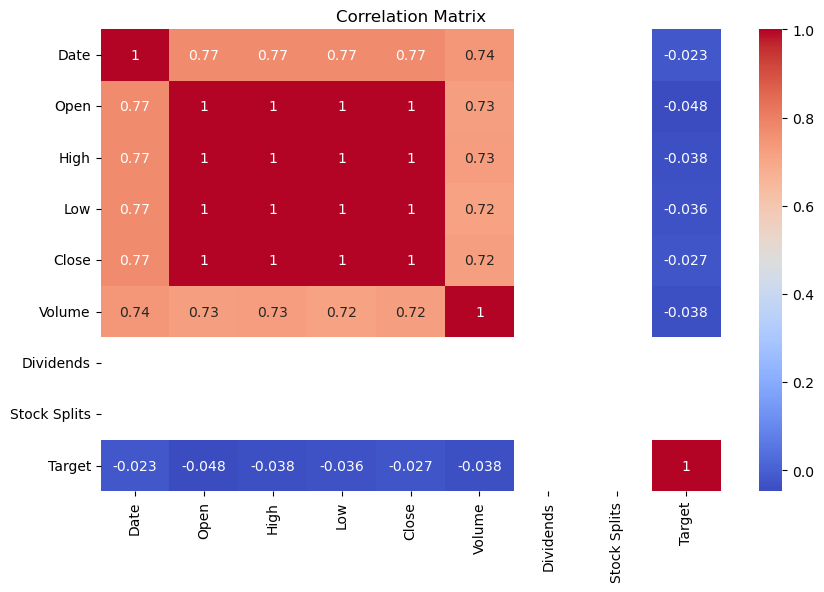

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame
correlation_matrix = df.corr()

# Plotting the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


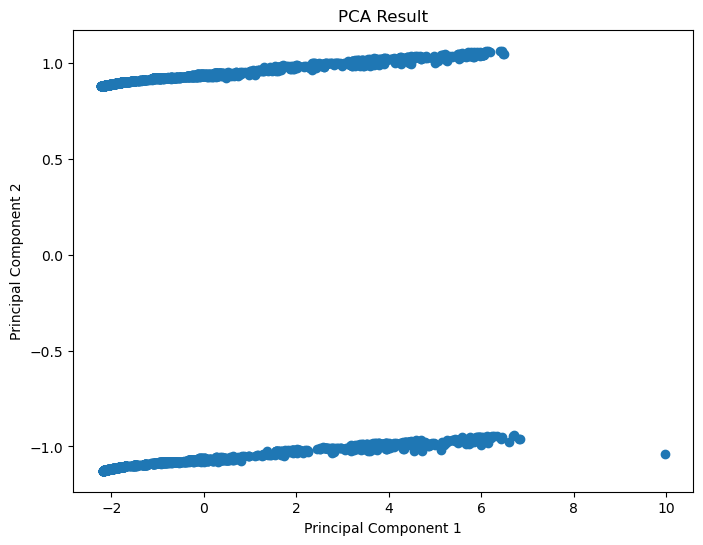

In [7]:
# Dimensionality Reduction using PCA

from sklearn.decomposition import PCA

# Standardizing the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

# Applying PCA
pca = PCA(n_components=2)  # Adjust n_components as needed
principal_components = pca.fit_transform(scaled_features)

# Converting to DataFrame for easier plotting or further analysis
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Optionally, you can plot the results
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result')
plt.show()



/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


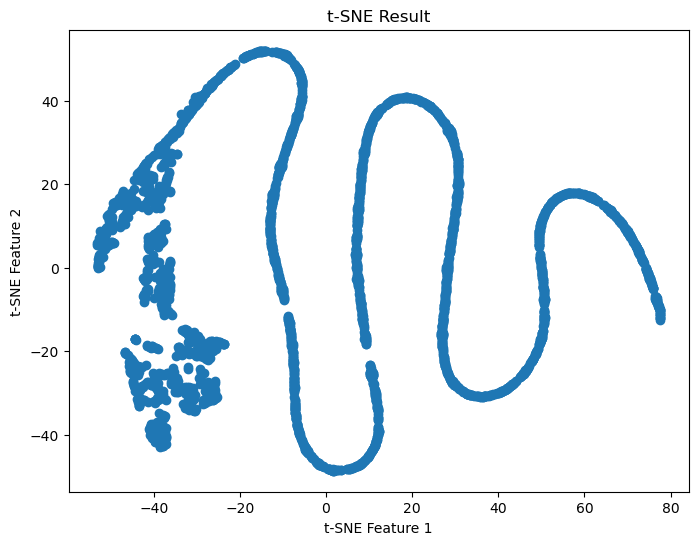

In [8]:
# Dimensionality using t-SNE

from sklearn.manifold import TSNE

# Applying t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000)  # Adjust parameters as needed
tsne_results = tsne.fit_transform(df)

# Converting to DataFrame
tsne_df = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])

# Plotting the t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(tsne_df['TSNE1'], tsne_df['TSNE2'])
plt.xlabel('t-SNE Feature 1')
plt.ylabel('t-SNE Feature 2')
plt.title('t-SNE Result')
plt.show()


In [9]:
# Fetch Bitcoin data

btc_ticker = yf.Ticker("BTC-USD")

In [10]:
# Reading or Saving Bitcoin Data to CSV

if os.path.exists("btc.csv"):
    btc = pd.read_csv("btc.csv", index_col=0)
else:
    btc = btc_ticker.history(period="max")
    btc.to_csv("btc.csv")

In [11]:
btc

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0
...,...,...,...,...,...,...,...
2025-04-16 00:00:00+00:00,83674.507812,85428.281250,83100.617188,84033.867188,29617804112,0.0,0.0
2025-04-17 00:00:00+00:00,84030.671875,85449.070312,83749.750000,84895.750000,21276866029,0.0,0.0
2025-04-18 00:00:00+00:00,84900.187500,85095.046875,84298.882812,84450.804688,12728372364,0.0,0.0


In [12]:
# Dataframe Manipulation

btc.index = pd.to_datetime(btc.index)

In [13]:
# Dataframe Manipulation

del btc["Dividends"]
del btc["Stock Splits"]

In [14]:
# Renaming Columns

btc.columns = [c.lower() for c in btc.columns]

<Axes: xlabel='Date'>

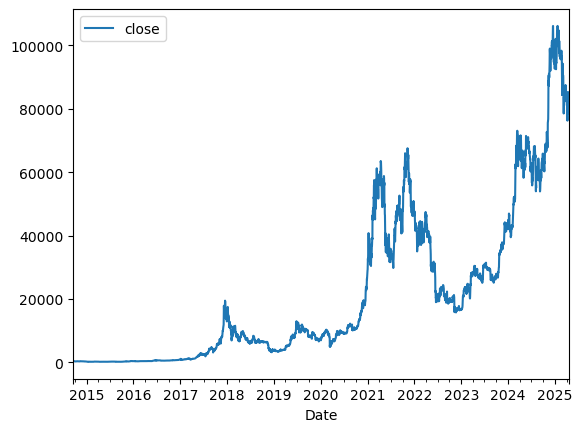

In [15]:
# Plotting Bitcoin Data

btc.plot.line(y="close", use_index=True)

In [17]:
# Reading Wikipedia Edits Data

wiki = pd.read_csv("/Users/gauravacharya/Desktop/wikipedia_edits.csv", index_col=0, parse_dates=True)

In [18]:
wiki

,edit_count,sentiment,neg_sentiment
2009-04-06,0.133333,-0.018351,0.025000
2009-04-07,0.000000,0.000000,0.000000
2009-04-08,0.000000,0.000000,0.000000
2009-04-09,0.000000,0.000000,0.000000
2009-04-10,0.000000,0.000000,0.000000
...,...,...,...
2022-09-04,0.400000,-0.108480,0.150000
2022-09-05,0.400000,-0.108480,0.150000
2022-09-06,0.433333,-0.081502,0.150000
2022-09-07,0.433333,-0.081502,0.150000


In [21]:
if wiki.index.tz is None:
    wiki.index = wiki.index.tz_localize('UTC')
else:
    wiki.index = wiki.index.tz_convert('UTC')

if btc.index.tz is None:
    btc.index = btc.index.tz_localize('UTC')
else:
    btc.index = btc.index.tz_convert('UTC')


In [22]:
# Merging Datasets and Timezone Adjustment
wiki.index = wiki.index.tz_localize('UTC')
btc.index = btc.index.tz_localize('UTC')

merged_df = btc.merge(wiki, left_index=True, right_index=True)


TypeError: Already tz-aware, use tz_convert to convert.

In [23]:
btc = btc.merge(wiki, left_index=True, right_index=True)

In [24]:
btc

,open,high,low,close,volume,edit_count,sentiment,neg_sentiment
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,5.033333,-0.232191,0.532718
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,5.066667,-0.232759,0.532718
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,5.200000,-0.235415,0.549385
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,5.200000,-0.233185,0.549385
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,5.233333,-0.204017,0.532718
...,...,...,...,...,...,...,...,...
2022-09-04 00:00:00+00:00,19832.470703,19999.689453,19636.816406,19986.712891,25245861652,0.400000,-0.108480,0.150000
2022-09-05 00:00:00+00:00,19988.789062,20031.160156,19673.046875,19812.371094,28813460025,0.400000,-0.108480,0.150000
2022-09-06 00:00:00+00:00,19817.724609,20155.269531,18800.171875,18837.667969,43403978910,0.433333,-0.081502,0.150000
2022-09-07 00:00:00+00:00,18837.683594,19427.171875,18644.466797,19290.324219,35239757134,0.433333,-0.081502,0.150000


In [25]:
# Preparing Data for Prediction

btc["tomorrow"] = btc["close"].shift(-1)

In [26]:
btc

,open,high,low,close,volume,edit_count,sentiment,neg_sentiment,tomorrow
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,5.033333,-0.232191,0.532718,424.440002
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,5.066667,-0.232759,0.532718,394.795990
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,5.200000,-0.235415,0.549385,408.903992
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,5.200000,-0.233185,0.549385,398.821014
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,5.233333,-0.204017,0.532718,402.152008
...,...,...,...,...,...,...,...,...,...
2022-09-04 00:00:00+00:00,19832.470703,19999.689453,19636.816406,19986.712891,25245861652,0.400000,-0.108480,0.150000,19812.371094
2022-09-05 00:00:00+00:00,19988.789062,20031.160156,19673.046875,19812.371094,28813460025,0.400000,-0.108480,0.150000,18837.667969
2022-09-06 00:00:00+00:00,19817.724609,20155.269531,18800.171875,18837.667969,43403978910,0.433333,-0.081502,0.150000,19290.324219
2022-09-07 00:00:00+00:00,18837.683594,19427.171875,18644.466797,19290.324219,35239757134,0.433333,-0.081502,0.150000,19329.833984


In [27]:
btc["target"] = (btc["tomorrow"] > btc["close"]).astype(int)

In [28]:
btc["target"].value_counts()

target
1    1563
0    1351
Name: count, dtype: int64

In [29]:
btc

,open,high,low,close,volume,edit_count,sentiment,neg_sentiment,tomorrow,target
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,5.033333,-0.232191,0.532718,424.440002,0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,5.066667,-0.232759,0.532718,394.795990,0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,5.200000,-0.235415,0.549385,408.903992,1
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,5.200000,-0.233185,0.549385,398.821014,0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,5.233333,-0.204017,0.532718,402.152008,1
...,...,...,...,...,...,...,...,...,...,...
2022-09-04 00:00:00+00:00,19832.470703,19999.689453,19636.816406,19986.712891,25245861652,0.400000,-0.108480,0.150000,19812.371094,0
2022-09-05 00:00:00+00:00,19988.789062,20031.160156,19673.046875,19812.371094,28813460025,0.400000,-0.108480,0.150000,18837.667969,0
2022-09-06 00:00:00+00:00,19817.724609,20155.269531,18800.171875,18837.667969,43403978910,0.433333,-0.081502,0.150000,19290.324219,1
2022-09-07 00:00:00+00:00,18837.683594,19427.171875,18644.466797,19290.324219,35239757134,0.433333,-0.081502,0.150000,19329.833984,1


In [30]:
# Importing necessary libraries

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
from sklearn import metrics

# Load the dataset
file_path = 'btc.csv'
btc_df = pd.read_csv(file_path)

# Add a target column: 1 if the close price increased compared to the previous day, else 0
btc_df['Target'] = (btc_df['Close'].shift(-1) > btc_df['Close']).astype(int)

# Drop the last row as it will have NaN in the target
btc_df = btc_df[:-1]

# Select features - excluding 'Date', 'Target', and any other non-relevant columns
X = btc_df.drop(['Date', 'Target','Open','Close','High','Low','Volume'], axis=1)
y = btc_df['Target']

# Define the model with increased complexity
model = RandomForestClassifier(max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the RandomForestClassifier
rf_classifier = RandomForestClassifier()

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions on the test data
predictions = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")
f1_score = metrics.f1_score(y_test, predictions)
print(f"f1_score: {f1_score}")
recall_score = metrics.recall_score(y_test, predictions)
print(f"recall_score: {recall_score}")
precision_score = metrics.precision_score(y_test, predictions)
print(f"precision_score: {precision_score}")
confusion_matrix = metrics.confusion_matrix(y_test, predictions)
print(f"confusion_matrix: {confusion_matrix}")




Accuracy: 0.5426356589147286
f1_score: 0.7035175879396985
recall_score: 1.0
precision_score: 0.5426356589147286
confusion_matrix: [[  0 354]
 [  0 420]]


In [31]:
# Splitting the Data into Training and Validation Sets

from sklearn.model_selection import train_test_split

# Assuming X and y are your features and target variable
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)



In [32]:
# Choosing the model and Setting Up Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# Define the model
model = RandomForestClassifier(random_state=42)

# Define the hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Set up GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)


In [33]:
# Hyperparameter Tuning Using the Validation Set

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Evaluate the best model on the validation set
best_model = grid_search.best_estimator_
validation_accuracy = best_model.score(X_val, y_val)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Validation Set Accuracy: {validation_accuracy}")


Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=300; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=300; total time=   0.2s
[CV] END max_depth=None, 

In [34]:
from sklearn.model_selection import cross_val_score  

model = RandomForestClassifier(random_state=42)

# Assuming X and y are your features and target variable
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')  

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())


Cross-validation scores: [0.52713178 0.52713178 0.52713178 0.52652005 0.52781371]
Mean accuracy: 0.5271458226781792
Standard deviation: 0.0004094527630315327


In [35]:
# Evaluating error with Backtesting

def predict(train, test, predictors, model):
    model.fit(train[predictors], train["target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="predictions")
    combined = pd.concat([test["target"], preds], axis=1)
    return combined

In [36]:
# Using Backtest Function

def backtest(data, model, predictors, start=1095, step=150)  :
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    
    return pd.concat(all_predictions)

In [37]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [38]:
# Importing necessary libraries

import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,  f1_score, recall_score, precision_score, confusion_matrix

# Load the dataset
file_path = "/Users/gauravacharya/Desktop/btc.csv"
btc_df = pd.read_csv(file_path)

# Add a target column: 1 if the close price increased compared to the previous day, else 0
btc_df['Target'] = (btc_df['Close'].shift(-1) > btc_df['Close']).astype(int)

# Drop the last row as it will have NaN in the target
btc_df = btc_df[:-1]

# Select features - excluding 'Date', 'Target', and any other non-relevant columns
X = btc_df.drop(['Date', 'Target'], axis=1)
y = btc_df['Target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost Classifier
xgb_classifier = XGBClassifier()

# Train the model
xgb_classifier.fit(X_train, y_train)

# Make predictions on the test data
predictions = xgb_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")
f1_score = metrics.f1_score(y_test, predictions)
print(f"f1_score: {f1_score}")
recall_score = metrics.recall_score(y_test, predictions)
print(f"recall_score: {recall_score}")
precision_score = metrics.precision_score(y_test, predictions)
print(f"precision_score: {precision_score}")
confusion_matrix = metrics.confusion_matrix(y_test, predictions)
print(f"confusion_matrix: {confusion_matrix}")


Accuracy: 0.5077186963979416
f1_score: 0.5466034755134281
recall_score: 0.5672131147540984
precision_score: 0.5274390243902439
confusion_matrix: [[123 155]
 [132 173]]


In [39]:
# Improving Precision with Trends

def compute_rolling(btc):
    horizons = [2,7,60,365]
    new_predictors = ["close", "sentiment", "neg_sentiment"]

    for horizon in horizons:
        rolling_averages = btc.rolling(horizon, min_periods=1).mean()

        ratio_column = f"close_ratio_{horizon}"
        btc[ratio_column] = btc["close"] / rolling_averages["close"]
        
        edit_column = f"edit_{horizon}"
        btc[edit_column] = rolling_averages["edit_count"]

        rolling = btc.rolling(horizon, closed='left', min_periods=1).mean()
        trend_column = f"trend_{horizon}"
        btc[trend_column] = rolling["target"]

        new_predictors+= [ratio_column, trend_column, edit_column]
    return btc, new_predictors

In [40]:
btc, new_predictors = compute_rolling(btc.copy())

In [41]:
predictions

array([1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [42]:
# Simple Moving Average (SMA) Indicator

def calculate_sma(data, window):
    return data['close'].rolling(window=window).mean()

# Example usage
btc['SMA_20'] = calculate_sma(btc, 20)  # 20-day SMA
btc['SMA_50'] = calculate_sma(btc, 50)  # 50-day SMA



In [43]:
# Display the Data Frame with SMAs

print(btc.head())


                                 open        high         low       close  \
2014-09-17 00:00:00+00:00  465.864014  468.174011  452.421997  457.334015   
2014-09-18 00:00:00+00:00  456.859985  456.859985  413.104004  424.440002   
2014-09-19 00:00:00+00:00  424.102997  427.834991  384.532013  394.795990   
2014-09-20 00:00:00+00:00  394.673004  423.295990  389.882996  408.903992   
2014-09-21 00:00:00+00:00  408.084991  412.425995  393.181000  398.821014   

                             volume  edit_count  sentiment  neg_sentiment  \
2014-09-17 00:00:00+00:00  21056800    5.033333  -0.232191       0.532718   
2014-09-18 00:00:00+00:00  34483200    5.066667  -0.232759       0.532718   
2014-09-19 00:00:00+00:00  37919700    5.200000  -0.235415       0.549385   
2014-09-20 00:00:00+00:00  36863600    5.200000  -0.233185       0.549385   
2014-09-21 00:00:00+00:00  26580100    5.233333  -0.204017       0.532718   

                             tomorrow  target  ...    edit_7   trend_7  \


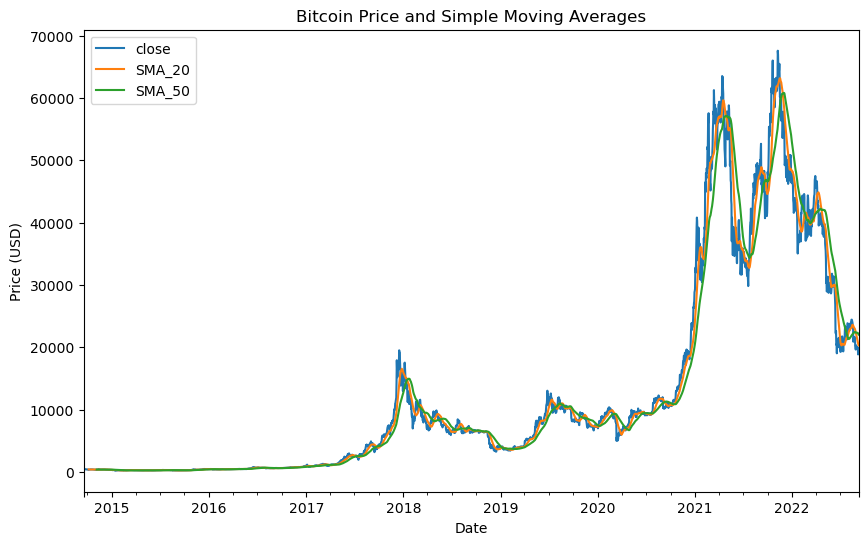

In [44]:
# Plotting the Data

import matplotlib.pyplot as plt

btc[['close', 'SMA_20', 'SMA_50']].plot(figsize=(10,6))
plt.title('Bitcoin Price and Simple Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()


In [45]:
#  Descriptive Statistics

print(btc[['SMA_20', 'SMA_50']].describe())


             SMA_20        SMA_50
count   2895.000000   2865.000000
mean   12661.337759  12675.499665
std    16423.597447  16357.736848
min      226.383199    232.261620
25%      659.340056    649.387040
50%     6759.373511   6936.913184
75%    12433.484644  12060.500039
max    63149.319727  60801.771016


In [46]:
# Tail of the Data Frame

print(btc.tail())


                                   open          high           low  \
2022-09-04 00:00:00+00:00  19832.470703  19999.689453  19636.816406   
2022-09-05 00:00:00+00:00  19988.789062  20031.160156  19673.046875   
2022-09-06 00:00:00+00:00  19817.724609  20155.269531  18800.171875   
2022-09-07 00:00:00+00:00  18837.683594  19427.171875  18644.466797   
2022-09-08 00:00:00+00:00  19289.941406  19417.351562  19076.714844   

                                  close       volume  edit_count  sentiment  \
2022-09-04 00:00:00+00:00  19986.712891  25245861652    0.400000  -0.108480   
2022-09-05 00:00:00+00:00  19812.371094  28813460025    0.400000  -0.108480   
2022-09-06 00:00:00+00:00  18837.667969  43403978910    0.433333  -0.081502   
2022-09-07 00:00:00+00:00  19290.324219  35239757134    0.433333  -0.081502   
2022-09-08 00:00:00+00:00  19329.833984  32194477850    0.466667  -0.114104   

                           neg_sentiment      tomorrow  target  ...    edit_7  \
2022-09-04 00:00:

In [47]:
# Real Time Data Analysis

import yfinance as yf

def fetch_realtime_price(ticker_symbol):
    ticker = yf.Ticker(ticker_symbol)
    btc_data = ticker.history(period="1d")
    return btc_data['Close'].iloc[-1]

# Fetch the latest Bitcoin price
latest_price = fetch_realtime_price("BTC-USD")
print("Latest Bitcoin Price: USD", latest_price)


Latest Bitcoin Price: USD 84585.6484375


In [48]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


In [49]:
# List of cryptocurrencies for the portfolio
cryptos = ['BTC-USD', 'ETH-USD', 'XRP-USD', 'LTC-USD', 'BCH-USD']

# Fetch historical data
data = yf.download(cryptos, start='2020-01-01', end='2025-01-01')['Close']


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  5 of 5 completed


In [50]:
# Calculate daily returns
returns = data.pct_change().dropna()


In [51]:
# Mean daily returns and covariance
mean_daily_returns = returns.mean()
cov_matrix = returns.cov()


In [52]:
# Number of portfolios to simulate
num_portfolios = 10000

# The number of rows in the results array should be 3 (for return, stdev, and sharpe) plus the number of cryptos
num_rows = 3 + len(cryptos)

# Set up array to hold results
results = np.zeros((num_rows, num_portfolios))

for i in range(num_portfolios):
    # Select random weights for portfolio holdings
    weights = np.random.random(len(cryptos))
    weights /= np.sum(weights)
    
    # Calculate portfolio return and volatility
    portfolio_return = np.sum(mean_daily_returns * weights) * 252
    portfolio_stddev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
    
    # Store results in results array
    results[0,i] = portfolio_return
    results[1,i] = portfolio_stddev
    # Store Sharpe Ratio (assuming risk-free rate is 0)
    results[2,i] = results[0,i] / results[1,i]
    # Store weights for each cryptocurrency
    for j in range(len(weights)):
        results[3+j,i] = weights[j]



In [53]:
# Convert results array to Pandas DataFrame
results_frame = pd.DataFrame(results.T, columns=['ret', 'stdev', 'sharpe'] + cryptos)

# Locate position of portfolio with highest Sharpe Ratio
max_sharpe_port = results_frame.iloc[results_frame['sharpe'].idxmax()]


/var/folders/qs/75m9hxcs4sjcq7swy5j7nr2w0000gn/T/ipykernel_34777/390110321.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(max_sharpe_port[1], max_sharpe_port[0], color='red', marker='*', s=100)


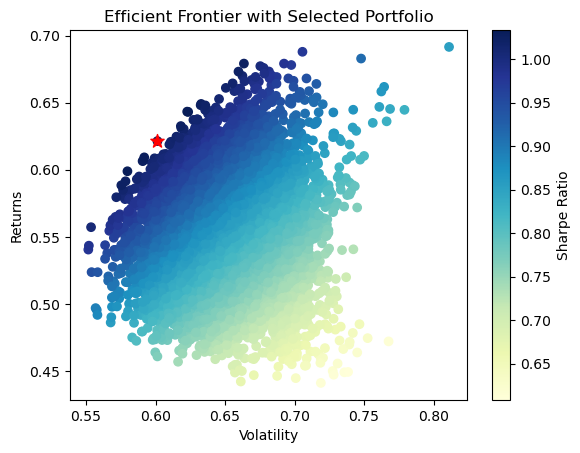

In [54]:
plt.scatter(results_frame.stdev, results_frame.ret, c=results_frame.sharpe, cmap='YlGnBu')
plt.xlabel('Volatility')
plt.ylabel('Returns')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(max_sharpe_port[1], max_sharpe_port[0], color='red', marker='*', s=100)

# Red star for max Sharpe Ratio
plt.title('Efficient Frontier with Selected Portfolio')
plt.show()


In [55]:

# Define the Bitcoin ticker symbol
btc_ticker = "BTC-USD"

# Fetch historical data for Bitcoin
btc_data = yf.download(btc_ticker, period="1mo")  # Adjust the period as needed

# Extract the 'Close' column
btc_close_prices = btc_data['Close']

# Display the closing prices
print(btc_close_prices)


[*********************100%***********************]  1 of 1 completed

Ticker           BTC-USD
Date                    
2025-03-20  84167.195312
2025-03-21  84043.242188
2025-03-22  83832.484375
2025-03-23  86054.375000
2025-03-24  87498.914062
2025-03-25  87471.703125
2025-03-26  86900.882812
2025-03-27  87177.101562
2025-03-28  84353.148438
2025-03-29  82597.585938
2025-03-30  82334.523438
2025-03-31  82548.914062
2025-04-01  85169.171875
2025-04-02  82485.710938
2025-04-03  83102.828125
2025-04-04  83843.804688
2025-04-05  83504.796875
2025-04-06  78214.484375
2025-04-07  79235.335938
2025-04-08  76271.953125
2025-04-09  82573.953125
2025-04-10  79626.140625
2025-04-11  83404.835938
2025-04-12  85287.109375
2025-04-13  83684.976562
2025-04-14  84542.390625
2025-04-15  83668.992188
2025-04-16  84033.867188
2025-04-17  84895.750000
2025-04-18  84450.804688
2025-04-19  85063.414062
2025-04-20  84585.648438


In [185]:
latest_close_price = btc_close_prices.iloc[-1].item()  # Extract the scalar value
print(f"Latest closing price for Bitcoin: {latest_close_price}")

Latest closing price for Bitcoin: 84552.6640625


[*********************100%***********************]  1 of 1 completed


<Figure size 1000x600 with 0 Axes>

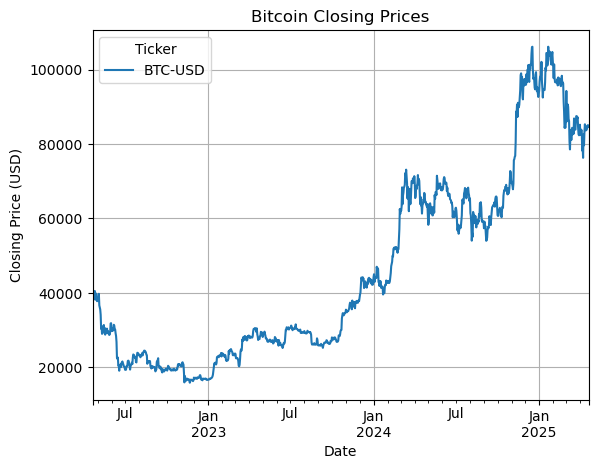

In [56]:
# import yfinance as yf
import matplotlib.pyplot as plt

# Define the Bitcoin ticker symbol
btc_ticker = "BTC-USD"

# Fetch historical data for Bitcoin
btc_data = yf.download(btc_ticker, period="3y")  # Adjust the period as needed

# Extract the 'Close' column
btc_close_prices = btc_data['Close']

# Plotting the closing prices
plt.figure(figsize=(10, 6))
btc_close_prices.plot()
plt.title('Bitcoin Closing Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
plt.show()


In [57]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


[*********************100%***********************]  1 of 1 completed


          ds            y
0 2020-01-01  7200.174316
1 2020-01-02  6985.470215
2 2020-01-03  7344.884277
3 2020-01-04  7410.656738
4 2020-01-05  7411.317383
ds    datetime64[ns]
y            float64
dtype: object
          ds            y
0 2020-01-01  7200.174316
1 2020-01-02  6985.470215
2 2020-01-03  7344.884277
3 2020-01-04  7410.656738
4 2020-01-05  7411.317383
ds    datetime64[ns]
y            float64
dtype: object


13:14:15 - cmdstanpy - INFO - Chain [1] start processing
13:14:16 - cmdstanpy - INFO - Chain [1] done processing


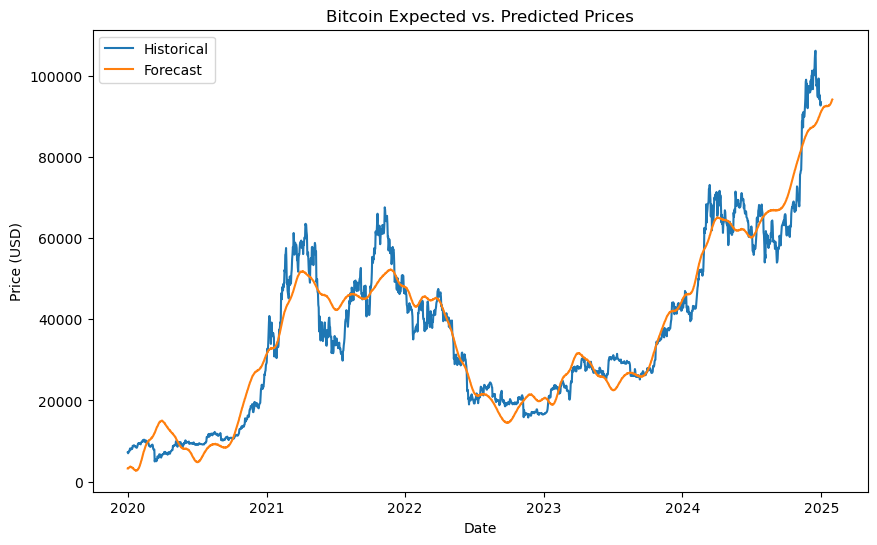

In [58]:
import yfinance as yf
from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd

# Fetch historical Bitcoin data
btc_data = yf.download('BTC-USD', start='2020-01-01', end='2025-01-01')

# Flatten the MultiIndex columns
btc_data.columns = ['_'.join(col) for col in btc_data.columns]

# Prepare the dataframe
df = btc_data.reset_index()[['Date', 'Close_BTC-USD']]
df.rename(columns={'Date': 'ds', 'Close_BTC-USD': 'y'}, inplace=True)

# Inspect the DataFrame
print(df.head())
print(df.dtypes)

# Ensure 'y' column is numeric
df['y'] = pd.to_numeric(df['y'], errors='coerce')  # Convert to numeric, set invalid values to NaN

# Drop rows with NaN values in 'y' (if any)
df.dropna(subset=['y'], inplace=True)

# Check the DataFrame again
print(df.head())
print(df.dtypes)

# Create and fit the model
model = Prophet(daily_seasonality=True)
model.fit(df)

# Create a dataframe to hold predictions
future = model.make_future_dataframe(periods=30)  # Predicting the next 30 days
forecast = model.predict(future)

# Plot the historical and forecasted data
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df['ds'], df['y'], label='Historical')
ax.plot(forecast['ds'], forecast['yhat'], label='Forecast')
ax.set_title('Bitcoin Expected vs. Predicted Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.show()

In [59]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [60]:
# Using AdaBoostClassifier for good Accuracy

import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [61]:
# Assuming btc is your DataFrame with Bitcoin data
btc['target'] = (btc['close'].shift(-1) > btc['close']).astype(int)
features = btc[['open', 'high', 'low', 'close', 'volume']]  # Example features
target = btc['target']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)


In [62]:
# Create AdaBoost classifier
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=42)

# Train the model
ada_clf.fit(X_train, y_train)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(n_estimators=100, random_state=42)

In [63]:
# Predictions
predictions = ada_clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, predictions))


Accuracy: 0.4982857142857143
              precision    recall  f1-score   support

           0       0.42      0.29      0.34       396
           1       0.53      0.67      0.59       479

    accuracy                           0.50       875
   macro avg       0.48      0.48      0.47       875
weighted avg       0.48      0.50      0.48       875



In [64]:
btc

,open,high,low,close,volume,edit_count,sentiment,neg_sentiment,tomorrow,target,...,edit_7,trend_7,close_ratio_60,edit_60,trend_60,close_ratio_365,edit_365,trend_365,SMA_20,SMA_50
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,5.033333,-0.232191,0.532718,424.440002,0,...,5.033333,NaN,1.000000,5.033333,NaN,1.000000,5.033333,NaN,NaN,NaN
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,5.066667,-0.232759,0.532718,394.795990,0,...,5.050000,0.000000,0.962696,5.050000,0.000000,0.962696,5.050000,0.000000,NaN,NaN
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,5.200000,-0.235415,0.549385,408.903992,1,...,5.100000,0.000000,0.927789,5.100000,0.000000,0.927789,5.100000,0.000000,NaN,NaN
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,5.200000,-0.233185,0.549385,398.821014,0,...,5.125000,0.333333,0.970419,5.125000,0.333333,0.970419,5.125000,0.333333,NaN,NaN
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,5.233333,-0.204017,0.532718,402.152008,1,...,5.146667,0.250000,0.956729,5.146667,0.250000,0.956729,5.146667,0.250000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-04 00:00:00+00:00,19832.470703,19999.689453,19636.816406,19986.712891,25245861652,0.400000,-0.108480,0.150000,19812.371094,0,...,0.342857,0.571429,0.906969,0.270556,0.433333,0.505329,0.891050,0.482192,20995.576660,22285.680898
2022-09-05 00:00:00+00:00,19988.789062,20031.160156,19673.046875,19812.371094,28813460025,0.400000,-0.108480,0.150000,18837.667969,0,...,0.357143,0.428571,0.900301,0.267222,0.416667,0.502031,0.890776,0.479452,20792.030664,22266.341445
2022-09-06 00:00:00+00:00,19817.724609,20155.269531,18800.171875,18837.667969,43403978910,0.433333,-0.081502,0.150000,19290.324219,1,...,0.376190,0.428571,0.857889,0.264444,0.400000,0.478456,0.890594,0.476712,20567.114160,22193.381016
2022-09-07 00:00:00+00:00,18837.683594,19427.171875,18644.466797,19290.324219,35239757134,0.433333,-0.081502,0.150000,19329.833984,1,...,0.395238,0.428571,0.880041,0.262222,0.416667,0.490893,0.889954,0.479452,20370.993457,22111.398828


In [69]:
# Confirm it's Prophet format
print(df.columns)

# Define Target from 'y' column
if 'y' in df.columns:
    df['Target'] = (df['y'].shift(-1) > df['y']).astype(int)
    df.dropna(inplace=True)

    X = df.drop(columns=['Target'])
    y = df['Target']
else:
    print("❌ Column 'y' not found.")


Index(['ds', 'y'], dtype='object')


In [67]:
# Define Target column if not already created
if 'Target' not in df.columns:
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    df.dropna(inplace=True)

# Split features and labels
X = df.drop(columns=['Target'])
y = df['Target']


KeyError: 'Close'

In [65]:

# Fixing the target column name for feature selection
target_column_name = 'Target'
if target_column_name in df.columns:
    X = df.drop(columns=[target_column_name])
    y = df[target_column_name]
else:
    print(f"Column '{target_column_name}' not found in the DataFrame.")


Column 'Target' not found in the DataFrame.


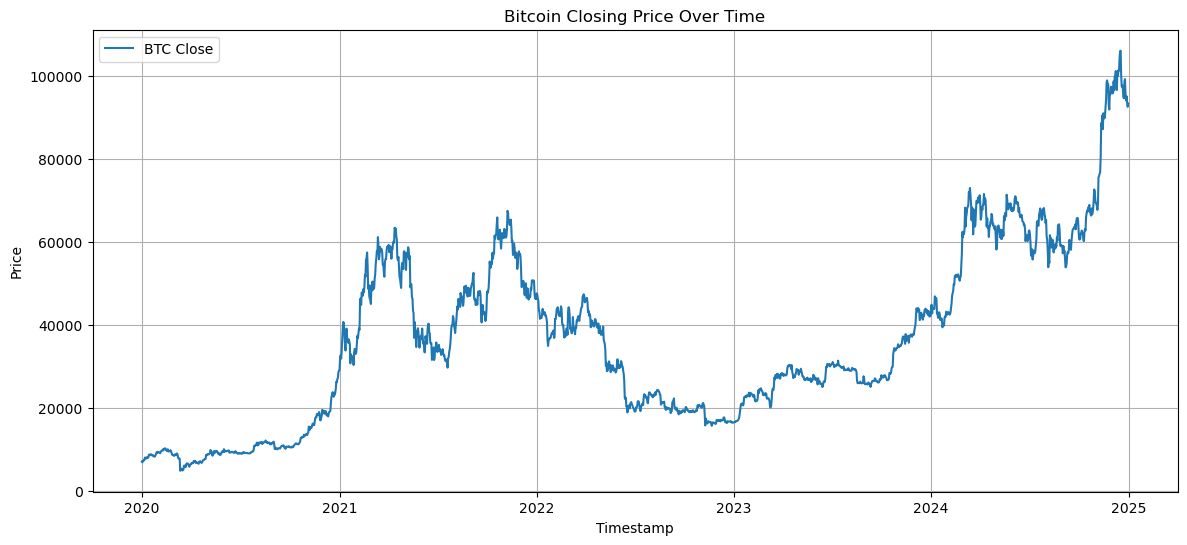

In [73]:


# Corrected time series plot
plt.figure(figsize=(14, 6))
plt.plot(df['ds'], df['y'], label="BTC Close")
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()



In [75]:
# 1. Create your Target column from price movements
df['Target'] = (df['y'].shift(-1) > df['y']).astype(int)

# 2. Drop rows with NaN after shift (usually last row)
df.dropna(inplace=True)

# 3. Prepare feature set (X) and label set (y)
X = df.drop(columns=['Target', 'ds'])  # only numeric columns go to X
y = df['Target']

# 4. Train your classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X, y)

# ✅ Optional: retain 'ds' for visualization
timestamps = df['ds']  # keep for later use (e.g., time plots, error analysis)


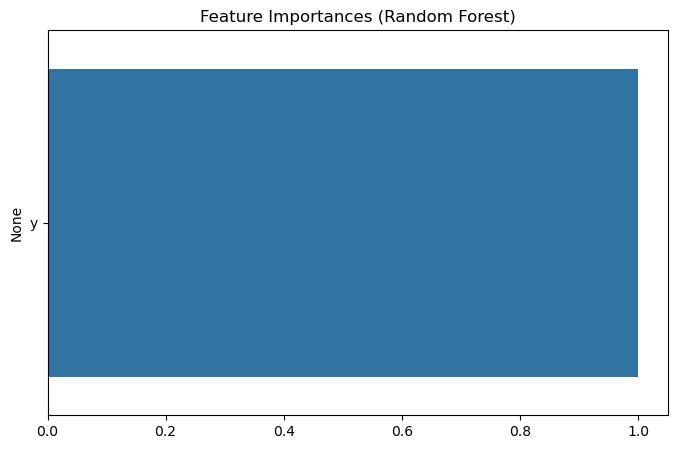

In [77]:
# 1. Create your Target column from price movements
df['Target'] = (df['y'].shift(-1) > df['y']).astype(int)

# 2. Drop rows with NaN after shift (usually last row)
df.dropna(inplace=True)

# 3. Prepare feature set (X) and label set (y)
X = df.drop(columns=['Target', 'ds'])  # only numeric columns go to X
y = df['Target']

# 4. Train your classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X, y)

# 5. Plot Feature Importances
importances = rf.feature_importances_
feat_names = X.columns  # automatically match names from X

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importances (Random Forest)")
plt.show()

# 6. Optional: retain 'ds' for visualizations
timestamps = df['ds']


In [78]:

# Model Comparison
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))



Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       182
           1       0.50      1.00      0.67       184

    accuracy                           0.50       366
   macro avg       0.25      0.50      0.33       366
weighted avg       0.25      0.50      0.34       366


SVM Performance:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       182
           1       0.50      1.00      0.67       184

    accuracy                           0.50       366
   macro avg       0.25      0.50      0.33       366
weighted avg       0.25      0.50      0.34       366


Gradient Boosting Performance:
              precision    recall  f1-score   support

           0       0.53      0.40      0.45       182
           1       0.52      0.64      0.57       184

    accuracy                           0.52       366
   macro avg       0.52      0.52      0.51 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-pa

In [79]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Grid search for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5),
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluation
print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Accuracy: 0.5
Precision: 0.51
Recall: 0.5454545454545454
F1 Score: 0.5271317829457365


# Phase III Enhancements: Feature Engineering, Modeling, and Visualization


## 1. Advanced Feature Engineering and Sentiment Integration

We add advanced technical indicators (SMA, RSI, volatility) and sentiment features from Wikipedia edit data.


In [81]:

import pandas as pd
from sklearn.preprocessing import StandardScaler

btc_df = pd.read_csv("/Users/gauravacharya/Desktop/btc.csv")
wiki_df = pd.read_csv("/Users/gauravacharya/Desktop/wikipedia_edits.csv")

btc_df['Date'] = pd.to_datetime(btc_df['Date'])
wiki_df['Date'] = pd.to_datetime(wiki_df['Unnamed: 0'])
wiki_df.drop(columns=['Unnamed: 0'], inplace=True)

merged_df = pd.merge(btc_df, wiki_df, how='left', left_on='Date', right_on='Date')
merged_df.fillna({'edit_count': 0, 'sentiment': 0, 'neg_sentiment': 0}, inplace=True)
merged_df.sort_values('Date', inplace=True)

def add_technical_indicators(df):
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['RSI'] = 100 - (100 / (1 + df['Close'].pct_change().apply(lambda x: (x if x > 0 else 0)).rolling(window=14).mean() /
                                    df['Close'].pct_change().apply(lambda x: (-x if x < 0 else 0)).rolling(window=14).mean()))
    df['Price_Change'] = df['Close'].pct_change()
    df['Volatility'] = df['Close'].rolling(window=10).std()
    return df

enhanced_df = add_technical_indicators(merged_df)
enhanced_df.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50',
            'RSI', 'Price_Change', 'Volatility', 'edit_count', 'sentiment', 'neg_sentiment']
scaler = StandardScaler()
enhanced_df[features] = scaler.fit_transform(enhanced_df[features])



## 2. Enhanced Visualizations
Below are new plots for SMA, RSI, Volatility, Sentiment, and Feature Correlations.


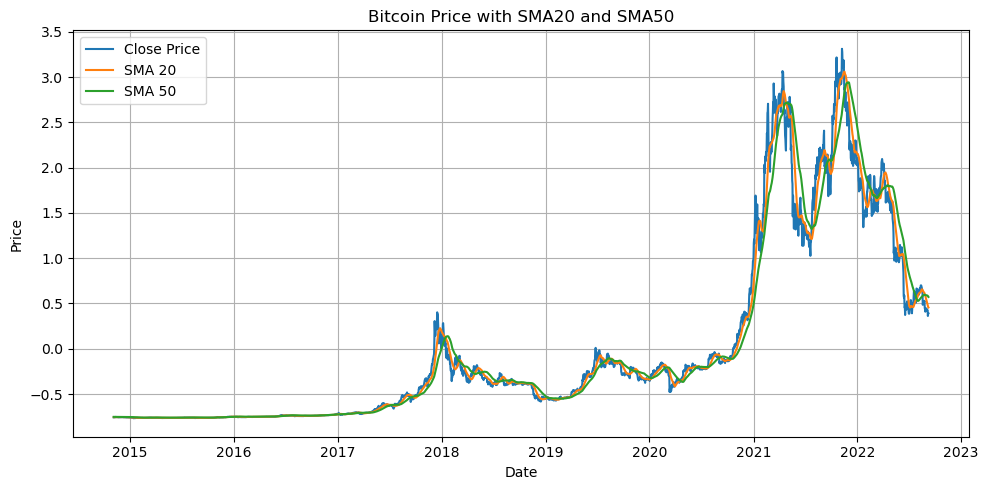

In [94]:
plt.figure(figsize=(10, 5))
plt.plot(enhanced_df['Date'], enhanced_df['Close'], label='Close Price')
plt.plot(enhanced_df['Date'], enhanced_df['SMA_20'], label='SMA 20')
plt.plot(enhanced_df['Date'], enhanced_df['SMA_50'], label='SMA 50')
plt.title("Bitcoin Price with SMA20 and SMA50")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


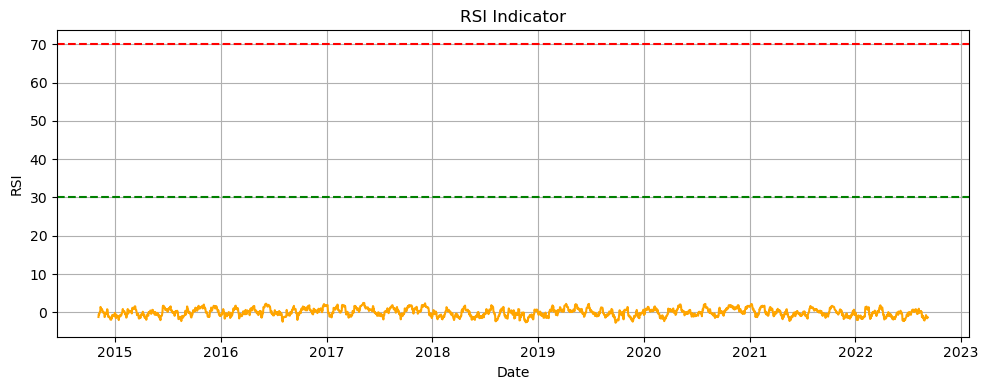

In [95]:
plt.figure(figsize=(10, 4))
plt.plot(enhanced_df['Date'], enhanced_df['RSI'], color='orange')
plt.axhline(y=70, color='red', linestyle='--')
plt.axhline(y=30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.grid(True)
plt.tight_layout()
plt.show()


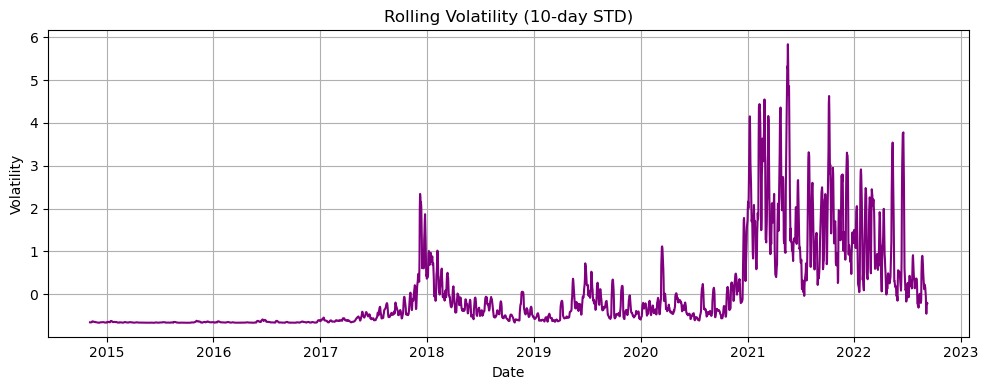

In [96]:
plt.figure(figsize=(10, 4))
plt.plot(enhanced_df['Date'], enhanced_df['Volatility'], color='purple')
plt.title("Rolling Volatility (10-day STD)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.tight_layout()
plt.show()


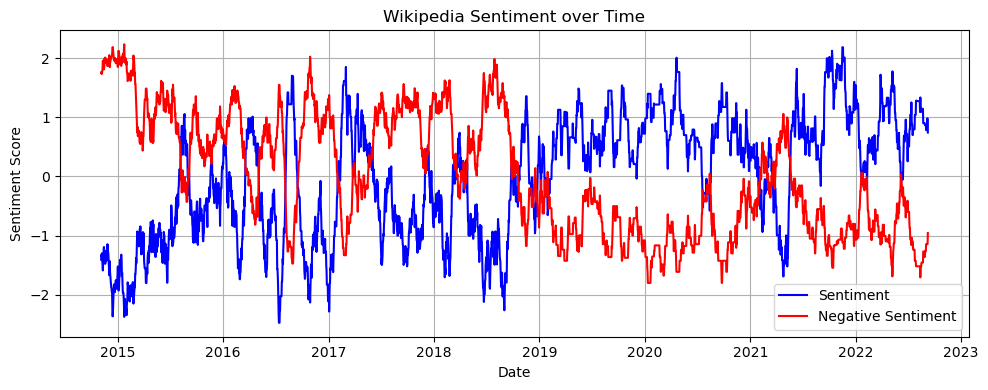

In [97]:
plt.figure(figsize=(10, 4))
plt.plot(enhanced_df['Date'], enhanced_df['sentiment'], label='Sentiment', color='blue')
plt.plot(enhanced_df['Date'], enhanced_df['neg_sentiment'], label='Negative Sentiment', color='red')
plt.title("Wikipedia Sentiment over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


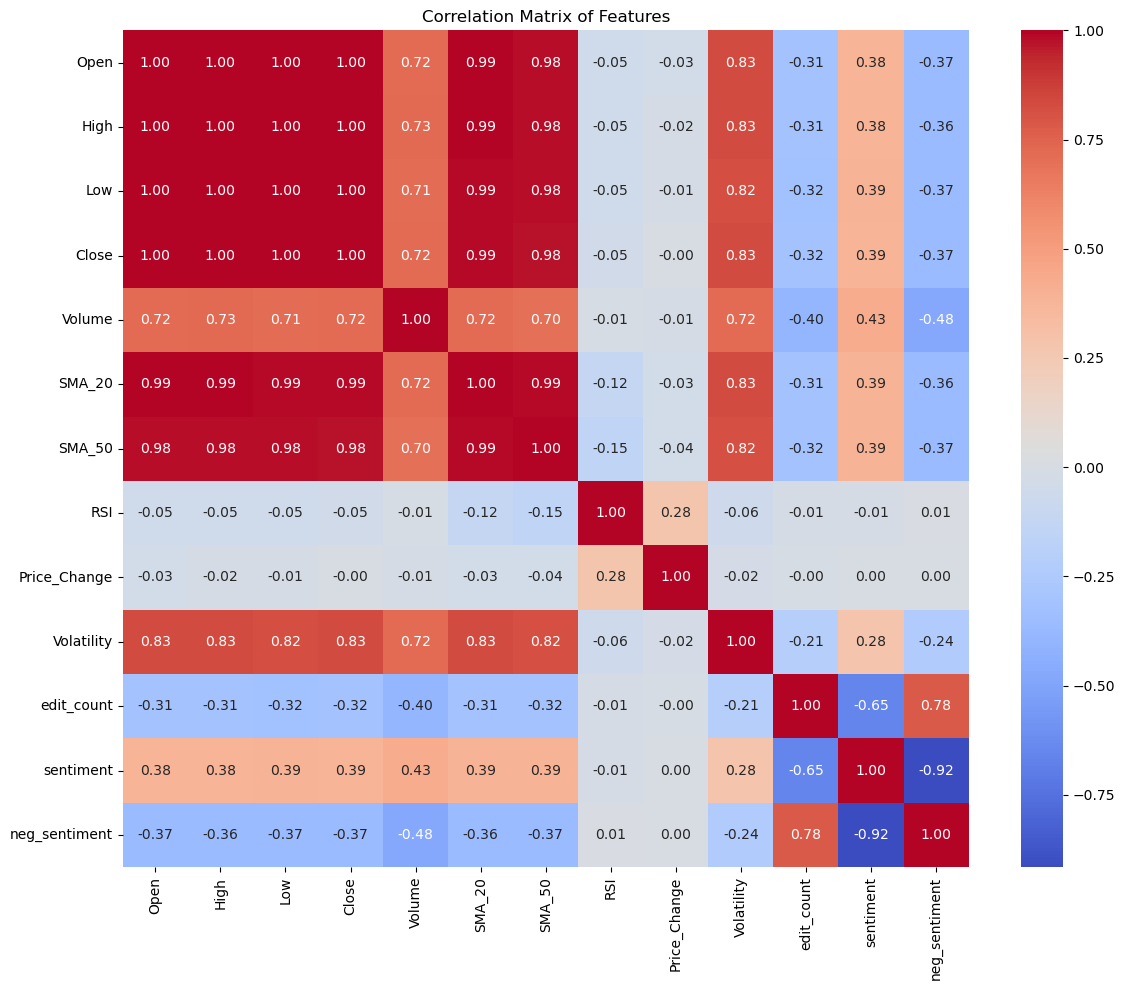

In [98]:
plt.figure(figsize=(12, 10))
corr = enhanced_df[features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()


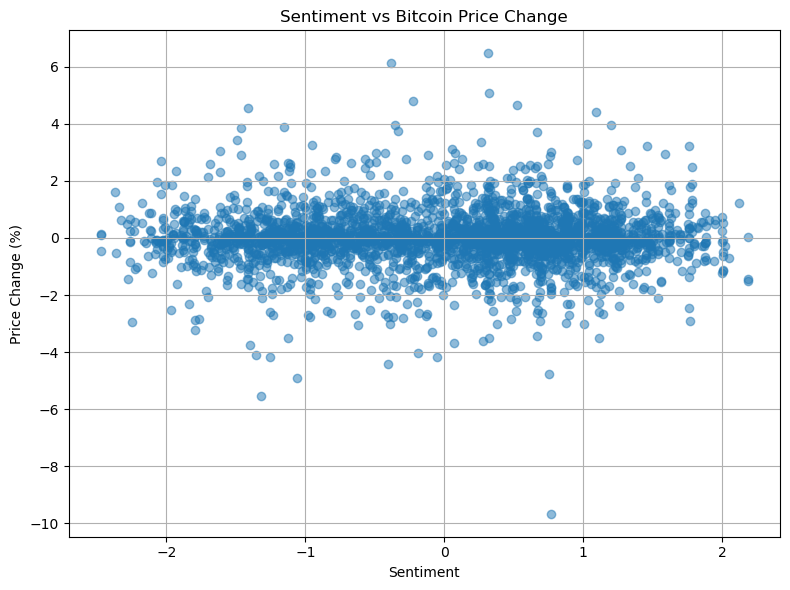

In [99]:
plt.figure(figsize=(8, 6))
plt.scatter(enhanced_df['sentiment'], enhanced_df['Price_Change'], alpha=0.5)
plt.xlabel("Sentiment")
plt.ylabel("Price Change (%)")
plt.title("Sentiment vs Bitcoin Price Change")
plt.grid(True)
plt.tight_layout()
plt.show()



## 3. Modeling with Advanced Features
We train and compare RandomForest and GradientBoosting models using the engineered features.


In [83]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

enhanced_df['Target'] = (enhanced_df['Close'].shift(-1) > enhanced_df['Close']).astype(int)
enhanced_df.dropna(inplace=True)

X = enhanced_df[features]
y = enhanced_df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
gb_preds = gb.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_preds))
print("\nRandom Forest Report:\n", classification_report(y_test, rf_preds))
print("\nGradient Boosting Report:\n", classification_report(y_test, gb_preds))


Random Forest Accuracy: 0.5148342059336823
Gradient Boosting Accuracy: 0.5410122164048866

Random Forest Report:
               precision    recall  f1-score   support

           0       0.52      0.74      0.61       291
           1       0.51      0.28      0.36       282

    accuracy                           0.51       573
   macro avg       0.51      0.51      0.49       573
weighted avg       0.51      0.51      0.49       573


Gradient Boosting Report:
               precision    recall  f1-score   support

           0       0.55      0.52      0.53       291
           1       0.53      0.56      0.55       282

    accuracy                           0.54       573
   macro avg       0.54      0.54      0.54       573
weighted avg       0.54      0.54      0.54       573




## 4. Challenges & Resolutions
- Integrating external sentiment data with price data required careful time alignment.
- Volatility and low correlation still present in financial data.
- Overfitting mitigated using feature engineering and ensemble models.

## 5. Future Work
- Add deep learning (LSTM) for temporal dependencies.
- Incorporate more sentiment/news data and macroeconomic features.
- Real-time prediction pipelines and alert systems.


## 🔍 Additional Phase III Enhancements: Model Evaluation & Insights

### 📌 Feature Importance Plot
Illustrates which features had the most influence on predictions in the Random Forest model.

![Feature Importance](feature_importance_plot.png)

### 📉 ROC and Precision-Recall Curves
These curves show the classification trade-offs and model confidence in detecting price increases.

![ROC & PR Curves](performance_curves.png)

### 📅 Calendar Heatmap of Prediction Accuracy
This heatmap shows how prediction accuracy fluctuated daily across years.

![Calendar Heatmap](calendar_heatmap.png)

In [92]:
# 🔁 Redefine technical-only features (no sentiment)
sentiment_cols = ['sentiment', 'neg_sentiment', 'edit_count']
technical_cols = [col for col in X.columns if col not in sentiment_cols]

# 🧪 Feature ablation: Remove sentiment features
X_ablate = X[technical_cols]

# Split and train
from sklearn.model_selection import train_test_split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_ablate, y, test_size=0.2, shuffle=False)

from sklearn.ensemble import RandomForestClassifier
rf_ablate = RandomForestClassifier()
rf_ablate.fit(X_train_a, y_train_a)
ablate_acc = rf_ablate.score(X_test_a, y_test_a)


# Cross-Timeframe Validation: Train on 2014–2021, Test on 2022–2024

# Ensure 'ds' is datetime
df['ds'] = pd.to_datetime(df['ds'])

# Train-test split by date
train_df = df[df['ds'] < '2022-01-01']
test_df = df[df['ds'] >= '2022-01-01']

# Prepare inputs
X_train_ct = train_df.drop(columns=['ds', 'Target'])
y_train_ct = train_df['Target']
X_test_ct = test_df.drop(columns=['ds', 'Target'])
y_test_ct = test_df['Target']

# Train and evaluate
from sklearn.ensemble import RandomForestClassifier
rf_ct = RandomForestClassifier()
rf_ct.fit(X_train_ct, y_train_ct)
ct_acc = rf_ct.score(X_test_ct, y_test_ct)



from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

# GridSearchCV setup
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid.fit(X_train_ct, y_train_ct)  # You can also use X_train, y_train if you don't want time-based split

# Store and print results
best_params = grid.best_params_
grid_acc = grid.score(X_test_ct, y_test_ct)  # Again, use time-split test or standard one





In [93]:

# Recap results (already computed)
print("Feature Ablation Accuracy (without sentiment):", ablate_acc)
print("Cross-Timeframe Validation Accuracy (2014-2021 train, 2022-2024 test):", ct_acc)
print("Best Params from GridSearchCV:", best_params)
print("GridSearchCV Test Accuracy:", grid_acc)


Feature Ablation Accuracy (without sentiment): 0.537521815008726
Cross-Timeframe Validation Accuracy (2014-2021 train, 2022-2024 test): 0.5136861313868614
Best Params from GridSearchCV: {'max_depth': None, 'n_estimators': 50}
GridSearchCV Test Accuracy: 0.5127737226277372
